# Tutorial: change the telescope position angle

This tutorial illustrates how telescope position angle changes the orientation of an on-sky source pattern on the focal plane. It also shows how `Pointing.from_coord()` converts an attitude defined in Galactic coordinates into the ICRS representation used internally by warpfield.

In the current design, attitude belongs to `Pointing`, not `Telescope`. The JASMINE telescope model is therefore constructed once and reused with several pointings.

## 1. Imports and plotting configuration

The figures follow the style of the preceding tutorials. Every focal-plane panel uses the same square limits, and those limits contain the complete circular JASMINE imaging field.

In [1]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np

matplotlib.rcParams['legend.frameon'] = False
matplotlib.rcParams['figure.dpi'] = 72

In [2]:
from astropy.coordinates import SkyCoord
from astropy.wcs import WCS
import astropy.units as u

from warpfield import Pointing, SourceCatalog
from warpfield.footprint import focalplane_footprints
from warpfield.model import get_jasmine

## 2. Load the artificial source pattern

`sample.coo` contains Galactic longitude and latitude in degrees around the Galactic center. Its sources form a recognizable J-shaped pattern, making rotations easy to see.

The telescope model accepts ICRS source positions, so we transform the Astropy `SkyCoord` and construct a `SourceCatalog`.

In [3]:
coordinates = np.loadtxt('data/sample.coo')
galactic_sources = SkyCoord(
  l=coordinates[:, 0] * u.deg,
  b=coordinates[:, 1] * u.deg,
  frame='galactic',
)
icrs_sources = galactic_sources.icrs
source = SourceCatalog(
  icrs_sources.ra.degree,
  icrs_sources.dec.degree,
)

galactic_center = SkyCoord(l=0.0 * u.deg, b=0.0 * u.deg, frame='galactic')

First display the input pattern on the sky. The WCS is centered at $(l, b) = (0°, 0°)$ with one arcsecond per display pixel. The limits are chosen symmetrically so that the source region is square.

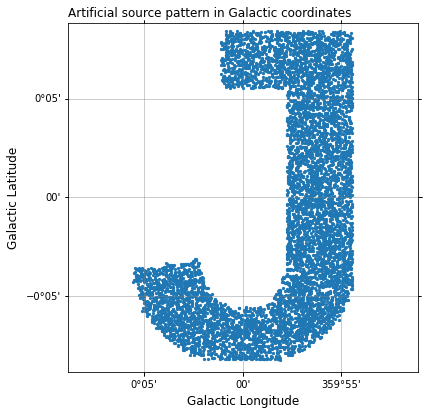

In [4]:
sky_wcs = WCS(naxis=2)
sky_wcs.wcs.crval = [0.0, 0.0]
sky_wcs.wcs.cdelt = [-1.0 / 3600, 1.0 / 3600]
sky_wcs.wcs.ctype = ['GLON-TAN', 'GLAT-TAN']
sky_wcs.wcs.cunit = ['deg', 'deg']

sky_coordinates = np.column_stack([
  galactic_sources.l.degree,
  galactic_sources.b.degree,
])
sky_xy = sky_wcs.wcs_world2pix(sky_coordinates, 0)
sky_center = sky_wcs.wcs_world2pix([[0.0, 0.0]], 0)[0]
sky_limit = 1.05 * np.abs(sky_xy - sky_center).max()

fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(projection=sky_wcs, label='galactic-sources')
ax.scatter(sky_xy[:, 0], sky_xy[:, 1], s=5)
ax.coords.grid(True, color='gray', alpha=0.5)
ax.set_xlim(sky_center[0] - sky_limit, sky_center[0] + sky_limit)
ax.set_ylim(sky_center[1] - sky_limit, sky_center[1] + sky_limit)
ax.set_aspect(1.0)
ax.set_title('Artificial source pattern in Galactic coordinates', loc='left')
ax.set_xlabel('Galactic Longitude', fontsize=12)
ax.set_ylabel('Galactic Latitude', fontsize=12)
fig.tight_layout()
plt.show()

## 3. Prepare the telescope and focal-plane plotting helpers

`get_jasmine(simulator=False)` returns the nominal telescope without simulation masks. Its four detector boundaries come from `focalplane_footprints()`.

The dashed circle represents `Optics.imaging_radius`. Every plot uses slightly wider square limits than this radius, so the full field of view is visible rather than being cropped to the source distribution.

In [5]:
jasmine = get_jasmine(simulator=False)
boundaries = focalplane_footprints(jasmine)
fov_radius = jasmine.optics.imaging_radius
plot_limit = 1.05 * fov_radius

In [6]:
def project_sources(telescope, pointing, source):
  size = len(source)
  return np.asarray(
    telescope.focal_plane(
      np.full(size, pointing.ra[0]),
      np.full(size, pointing.dec[0]),
      np.full(size, pointing.position_angle[0]),
      source.ra,
      source.dec,
      np.ones((size, 1)),
    )
  )


def plot_focal_plane(ax, telescope, pointing, source, title):
  source_xy = project_sources(telescope, pointing, source)
  ax.scatter(source_xy[:, 0], source_xy[:, 1], s=5)
  for detector_id, boundary in enumerate(boundaries):
    N = boundary.shape[0]
    ax.scatter(
      boundary[0, 0],
      boundary[0, 1],
      color=f'C{detector_id}',
      marker='o',
      s=25,
    )
    ax.plot(
      boundary[: N // 4 + 1, 0],
      boundary[: N // 4 + 1, 1],
      color=f'C{detector_id}',
      lw=3,
    )
    ax.plot(
      boundary[:, 0],
      boundary[:, 1],
      color=f'C{detector_id}',
      lw=1,
    )
  ax.add_patch(
    plt.Circle(
      (0.0, 0.0),
      fov_radius,
      fill=False,
      color='gray',
      linestyle='--',
      lw=1,
    )
  )

  ax.grid(True, color='gray', alpha=0.5)
  ax.set_xlim(-plot_limit, plot_limit)
  ax.set_ylim(-plot_limit, plot_limit)
  ax.set_aspect(1.0, adjustable='box')
  ax.set_title(title, loc='left')
  ax.set_xlabel('Focal plane X (mm)', fontsize=12)
  ax.set_ylabel('Focal plane Y (mm)', fontsize=12)

## 4. Compare position angles in the Galactic frame

`Pointing.from_coord('galactic', lon, lat, pa)` interprets the position angle east of Galactic north, then converts the complete attitude into ICRS. Increasing the telescope position angle rotates the projected source pattern in the opposite direction on the fixed focal-plane axes.

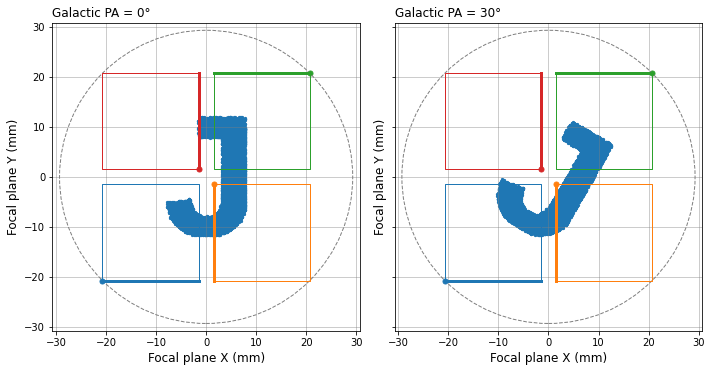

In [7]:
galactic_pa0 = Pointing.from_coord('galactic', 0.0, 0.0, 0.0)
galactic_pa30 = Pointing.from_coord('galactic', 0.0, 0.0, 30.0)

fig, axes = plt.subplots(
  1,
  2,
  figsize=(10, 5),
  sharex=True,
  sharey=True,
  subplot_kw={'box_aspect': 1},
)
plot_focal_plane(
  axes[0],
  jasmine,
  galactic_pa0,
  source,
  title='Galactic PA = 0°',
)
plot_focal_plane(
  axes[1],
  jasmine,
  galactic_pa30,
  source,
  title='Galactic PA = 30°',
)
fig.tight_layout()
plt.show()

## 5. Describe the same attitude in different frames

A position angle of 0° in ICRS points toward ICRS north, not Galactic north. At the Galactic center, ICRS north has a non-zero position angle in the Galactic frame.

We determine that Galactic angle geometrically: offset the center a short distance toward ICRS north, transform the direction to Galactic coordinates, and measure its Galactic position angle. The two resulting `Pointing` objects should describe the same physical attitude.

In [8]:
icrs_center = galactic_center.icrs
icrs_north = icrs_center.directional_offset_by(0.0 * u.deg, 1.0 * u.arcsec)
galactic_pa_for_icrs_north = galactic_center.position_angle(
  icrs_north.galactic
)

icrs_pa0 = Pointing.from_coord('icrs', icrs_center.ra, icrs_center.dec, 0.0)
equivalent_galactic = Pointing.from_coord(
  'galactic',
  galactic_center.l,
  galactic_center.b,
  galactic_pa_for_icrs_north,
)

print(
  'Galactic PA of ICRS north:',
  galactic_pa_for_icrs_north.to_value(u.deg),
  'deg',
)
print('Internal ICRS PA:', np.asarray(icrs_pa0.position_angle))
print(
  'Converted Galactic attitude:',
  np.asarray(equivalent_galactic.position_angle),
)

Galactic PA of ICRS north: 58.59866213589664 deg
Internal ICRS PA: [0.]
Converted Galactic attitude: [0.]


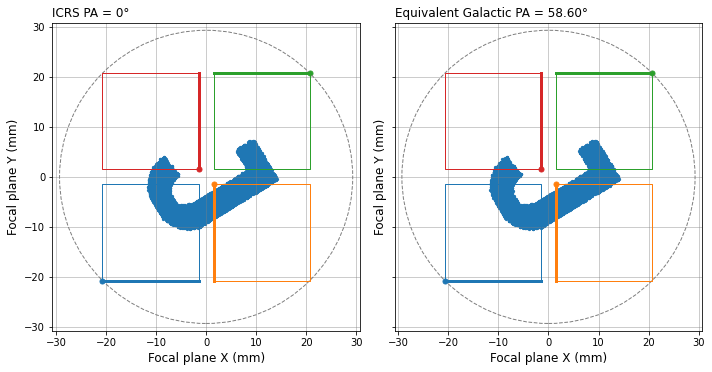

In [9]:
fig, axes = plt.subplots(
  1,
  2,
  figsize=(10, 5),
  sharex=True,
  sharey=True,
  subplot_kw={'box_aspect': 1},
)
plot_focal_plane(
  axes[0],
  jasmine,
  icrs_pa0,
  source,
  title='ICRS PA = 0°',
)
plot_focal_plane(
  axes[1],
  jasmine,
  equivalent_galactic,
  source,
  title=(f'Equivalent Galactic PA = {galactic_pa_for_icrs_north.degree:.2f}°'),
)
fig.tight_layout()
plt.show()

## Summary

- Position angle is an exposure-level attitude parameter stored by `Pointing`.
- `Pointing.from_coord()` accepts ICRS or Galactic longitude, latitude, and position angle and stores the equivalent ICRS attitude.
- Changing position angle rotates the sky relative to the fixed detector layout.
- Position angles are frame-dependent, but attitudes converted from different frames agree when they describe the same direction and orientation.
- All focal-plane panels use common square limits containing the complete circular imaging field.